In [1]:
import numpy as np
import pandas as pd


In [5]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [7]:
df=pd.read_csv("Churn_Modelling.csv")

In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.shape

(10000, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [14]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [15]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [16]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [17]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [30]:
# using OHE to both(Geography, Gender)
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [31]:
X=df.drop(columns=['Exited'])
Y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=1)

In [32]:
print(X_train.dtypes)

CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object


In [33]:
X_train.shape

(8000, 11)

In [34]:
# Scaling because some values are bigger and some not
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [45]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [82]:
model=Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(8,activation='relu'))
model.add(Dense(5,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [83]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279 (1.09 KB)

 Trainable params: 279 (1.09 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [91]:
history=model.fit(X_train_scaled,Y_train,epochs=20,validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8594 - loss: 0.3452 - val_accuracy: 0.8494 - val_loss: 0.3440
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8572 - loss: 0.3442 - val_accuracy: 0.8512 - val_loss: 0.3426
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8584 - loss: 0.3428 - val_accuracy: 0.8506 - val_loss: 0.3450
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8581 - loss: 0.3427 - val_accuracy: 0.8537 - val_loss: 0.3419
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8600 - loss: 0.3412 - val_accuracy: 0.8537 - val_loss: 0.3412
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8606 - loss: 0.3408 - val_accuracy: 0.8487 - val_loss: 0.3416
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8592 - loss: 0.3403 - val_accuracy: 0.8519 - val_loss: 0.3410
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8631 - loss: 0.3395 - val_accuracy: 0.

In [86]:
model.layers[0].get_weights()

[array([[ 2.24928007e-01,  2.70390749e-01,  1.09012052e-01,
         -8.18739980e-02,  1.55631959e-01,  1.86589006e-02,
         -2.96477764e-03, -1.41580328e-02,  7.74019733e-02,
         -6.51493715e-03, -2.13898391e-01],
        [ 3.92057478e-01, -1.49901593e+00,  2.34945327e-01,
         -1.51329100e+00, -2.73293495e-01,  3.79211038e-01,
          1.84613094e-02, -2.37346757e-02, -1.05988324e+00,
          3.95147741e-01, -9.70775113e-02],
        [ 1.80937633e-01, -2.41929181e-02,  1.30597293e-01,
          3.01975477e-02, -9.33971480e-02,  1.77320048e-01,
         -9.29891765e-02,  3.33062708e-01, -1.85184672e-01,
         -4.33940113e-01,  2.81569868e-01],
        [-7.42497683e-01, -7.30713680e-02,  4.88593459e-01,
         -8.70232284e-02,  4.34543997e-01, -9.51081753e-01,
         -6.25270605e-01,  1.10070594e-01,  6.03318997e-02,
          5.35355568e-01, -4.58943367e-01],
        [-8.90739620e-01, -2.31389612e-01,  6.12699568e-01,
         -3.00294578e-01,  1.43699706e-01,  

In [87]:
y_log=model.predict(X_test_scaled)
y_pred=np.where(y_log>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [88]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.853

In [93]:
history.history

{'accuracy': [0.859375,
  0.8571875095367432,
  0.8584374785423279,
  0.8581249713897705,
  0.8600000143051147,
  0.8606250286102295,
  0.8592187762260437,
  0.8631250262260437,
  0.8609374761581421,
  0.8612499833106995,
  0.8626562356948853,
  0.8609374761581421,
  0.8620312213897705,
  0.8615624904632568,
  0.864062488079071,
  0.8610937595367432,
  0.8615624904632568,
  0.8618749976158142,
  0.8629687428474426,
  0.8609374761581421],
 'loss': [0.3452051281929016,
  0.3442169427871704,
  0.34277021884918213,
  0.34265777468681335,
  0.3411637544631958,
  0.3408468961715698,
  0.34030434489250183,
  0.33950871229171753,
  0.33874884247779846,
  0.3388737738132477,
  0.33817023038864136,
  0.33745861053466797,
  0.3372364044189453,
  0.33639657497406006,
  0.3364204168319702,
  0.3355489671230316,
  0.3356797695159912,
  0.33493414521217346,
  0.3347949683666229,
  0.3344532251358032],
 'val_accuracy': [0.8493750095367432,
  0.8512499928474426,
  0.8506249785423279,
  0.85374999046325

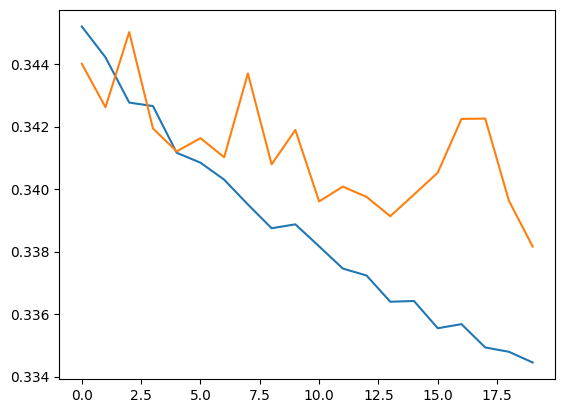

In [95]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

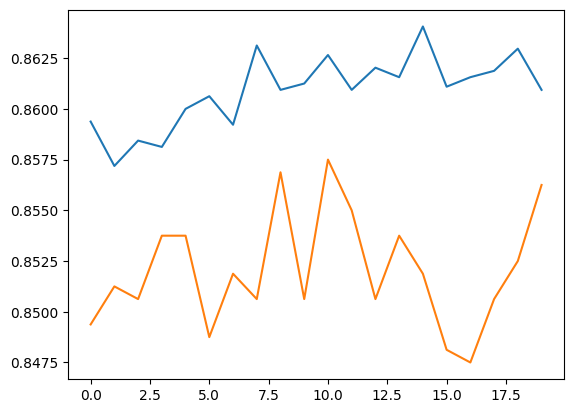

In [97]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])